# Análise Sociodemográfica sob a Lente do Viés de Excesso de Confiança

**Dataset:** Vieses Cognitivos na Tomada de Decisão Financeira  
**Total de respondentes:** 279

---

## Contexto e Objetivo

O **excesso de confiança** (*overconfidence bias*) é um dos vieses cognitivos mais documentados na literatura de finanças comportamentais. Ele descreve a tendência que as pessoas têm de superestimar suas próprias capacidades, conhecimentos ou a precisão de suas previsões — especialmente em domínios complexos como finanças pessoais e investimentos.

Este notebook tem como objetivo **testar se variáveis sociodemográficas** — como gênero, idade, escolaridade e renda — estão associadas a diferentes níveis de excesso de confiança financeiro nos respondentes do questionário.

---

## Como o Excesso de Confiança é Medido Aqui

O questionário contém **5 afirmações** sobre autopercepção financeira, respondidas em uma **escala Likert de 5 pontos**:

| Resposta | Valor numérico |
|---|---|
| Discordo totalmente | 1 |
| Discordo | 2 |
| Nem concordo e nem discordo | 3 |
| Concordo | 4 |
| Concordo totalmente | 5 |

Os 5 itens são:

| Código | Afirmação |
|---|---|
| EC1 | Tenho um maior conhecimento financeiro para tomar decisões sobre o uso do dinheiro do que a minha família. |
| EC2 | Gerencio o dinheiro melhor do que meus amigos ou familiares. |
| EC3 | Acredito que os conhecimentos financeiros que possuo me ajudam a tomar as melhores decisões. |
| EC4 | Tenho mais confiança nas minhas opiniões a respeito de produtos financeiros do que na opinião de especialistas. |
| EC5 | Tenho boas expectativas quanto ao meu futuro financeiro. |

O **Score de Excesso de Confiança (Score EC)** de cada respondente é a **média aritmética** dos valores numéricos dos 5 itens, resultando em um número entre 1 e 5.

> **Interpretação:** Quanto maior o Score EC, mais o respondente concorda com afirmações que indicam superestimação de sua competência financeira em relação a outras pessoas ou especialistas.

Adicionalmente, criamos uma **classificação binária**: respondentes com Score EC ≥ 3,5 são classificados como portadores de **alto excesso de confiança**.

---

## Sobre a Literacia Financeira Objetiva

Para a Hipótese 5, utilizamos um conjunto de **7 questões de conhecimento financeiro objetivo** — ou seja, perguntas com resposta certa e errada (gabarito conhecido). O **Score de Literacia Financeira (Score LF)** é a contagem de acertos (0 a 7).

Esse score serve como medida independente do *conhecimento real* do respondente, em contraste com o Score EC, que mede a *autopercepção de conhecimento*. A divergência entre os dois é o núcleo do efeito Dunning-Kruger.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, spearmanr
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

---
## Célula 1 — Carregamento e Renomeação das Colunas

O arquivo CSV é carregado com `pandas`. As colunas do Google Forms possuem nomes extensos (o texto completo da pergunta), por isso criamos um dicionário `col_map` que associa cada coluna original ao seu nome abreviado.

As colunas são selecionadas pelos seus **índices posicionais** (0, 1, 2...), pois o texto completo das perguntas pode variar ligeiramente entre versões do formulário.

In [12]:
df_raw = pd.read_csv('Vieses_Cognitivos_na_Tomada_de_Decisão_Financeira__respostas__-_Respostas_ao_formulário_1_1_.csv')

col_map = {
    df_raw.columns[3]:  'idade',
    df_raw.columns[4]:  'genero',
    df_raw.columns[5]:  'raca_cor',
    df_raw.columns[6]:  'regiao',
    df_raw.columns[8]:  'tipo_localidade',
    df_raw.columns[9]:  'renda',
    df_raw.columns[10]: 'ocupacao',
    df_raw.columns[11]: 'escolaridade',
    df_raw.columns[12]: 'estado_civil',
    df_raw.columns[14]: 'n_pessoas_casa',
    df_raw.columns[16]: 'responsavel_financeiro',
    df_raw.columns[17]: 'escolaridade_resp_financeiro',
    df_raw.columns[31]: 'ec1_conhecimento_vs_familia',
    df_raw.columns[32]: 'ec2_gerencio_melhor',
    df_raw.columns[33]: 'ec3_conhecimento_melhores_decisoes',
    df_raw.columns[34]: 'ec4_confianca_vs_especialistas',
    df_raw.columns[35]: 'ec5_expectativas_futuro',
    df_raw.columns[55]: 'lf1_desconto_televisor',
    df_raw.columns[56]: 'lf2_juros_emprestimo',
    df_raw.columns[57]: 'lf3_poupanca_2pct',
    df_raw.columns[58]: 'lf4_inflacao_vs_juros',
    df_raw.columns[59]: 'lf5_ativo_volatil',
    df_raw.columns[60]: 'lf6_retorno_risco',
    df_raw.columns[61]: 'lf7_dobrar_emprestimo',
    df_raw.columns[43]: 'tem_investimento',
    df_raw.columns[47]: 'ja_passou_dificuldade',
}

df = df_raw.rename(columns=col_map).copy()
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')

Linhas: 279 | Colunas: 69


---
## Célula 2 — Parser Likert Robusto e Construção do Score EC

### Por que um parser robusto?

Formulários do Google Forms podem registrar **respostas duplicadas** em uma mesma célula quando o respondente altera sua resposta (ex: `'Discordo, Concordo'`). Uma tradução direta com `map()` retornaria `NaN` para esses casos, contaminando o Score EC com valores ausentes.

A função `parse_likert()` resolve isso da seguinte forma:
1. Tenta mapear o valor diretamente pelo dicionário `LIKERT`.
2. Se não encontrar, divide o valor pela vírgula e calcula a **média** dos valores reconhecidos.
3. Se nenhum valor for reconhecido, retorna `NaN`.

### Construção do Score EC

Após converter os 5 itens para valores numéricos, o Score EC é calculado como a **média aritmética** de EC1 a EC5 para cada respondente. Isso resulta em um número contínuo de 1 a 5.

A **classificação binária** `alto_ec` é definida pelo limiar de 3,5 — equivalente a estar, em média, acima da opção neutra da escala.

In [13]:
LIKERT = {
    'Discordo totalmente':         1,
    'Discordo':                    2,
    'Nem concordo, nem discordo':  3,
    'Nem concordo e nem discordo': 3,
    'Concordo':                    4,
    'Concordo totalmente':         5,
}

def parse_likert(val):
    """Converte resposta Likert textual para numérico.
    Lida com respostas duplicadas separadas por vírgula."""
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val in LIKERT:
        return LIKERT[val]
    parts  = [p.strip() for p in val.split(',')]
    scores = [LIKERT[p] for p in parts if p in LIKERT]
    return np.mean(scores) if scores else np.nan

ec_cols = [
    'ec1_conhecimento_vs_familia',
    'ec2_gerencio_melhor',
    'ec3_conhecimento_melhores_decisoes',
    'ec4_confianca_vs_especialistas',
    'ec5_expectativas_futuro',
]

for col in ec_cols:
    df[col] = df[col].apply(parse_likert)

df['score_ec'] = df[ec_cols].mean(axis=1)
df['alto_ec']  = (df['score_ec'] >= 3.5).astype(int)

print('=== Distribuição do Score EC ===')
print(df['score_ec'].describe().round(2))
print(f"\nRespostas válidas : {df['score_ec'].notna().sum()} / {len(df)}")
print(f"Alto EC (score ≥ 3.5): {df['alto_ec'].sum()} respondentes ({df['alto_ec'].mean()*100:.1f}%)")

=== Distribuição do Score EC ===
count    277.00
mean       3.34
std        0.81
min        1.00
25%        2.80
50%        3.20
75%        3.80
max        5.00
Name: score_ec, dtype: float64

Respostas válidas : 277 / 279
Alto EC (score ≥ 3.5): 114 respondentes (40.9%)


---
## Célula 3 — Literacia Financeira Objetiva (Score LF)

Cada uma das 7 questões de conhecimento financeiro possui um gabarito definido. Para cada respondente, verificamos se a resposta coincide exatamente com o gabarito, atribuindo **1 ponto para acerto e 0 para erro**.

O **Score LF** é a soma dos acertos, variando de **0 (nenhum acerto) a 7 (acerto total)**.

Esse score representa o conhecimento financeiro **objetivo** do respondente — em oposição ao Score EC, que representa o conhecimento **percebido**.

In [14]:
gabaritos = {
    'lf1_desconto_televisor':  'Loja A (desconto de R$150,00)',
    'lf2_juros_emprestimo':    'Nenhum juro',
    'lf3_poupanca_2pct':       'R$102,00',
    'lf4_inflacao_vs_juros':   'Menos do que hoje',
    'lf5_ativo_volatil':       'Ações',
    'lf6_retorno_risco':       'Verdadeira',
    'lf7_dobrar_emprestimo':   'Entre 3 e 5 anos',
}

for col, gab in gabaritos.items():
    df[f'{col}_ok'] = (df[col].str.strip() == gab.strip()).astype(int)

lf_ok_cols   = [f'{c}_ok' for c in gabaritos]
df['score_lf'] = df[lf_ok_cols].sum(axis=1)

print('=== Distribuição do Score LF (0–7) ===')
print(df['score_lf'].describe().round(2))
print('\nContagem por pontuação:')
print(df['score_lf'].value_counts().sort_index())

=== Distribuição do Score LF (0–7) ===
count    279.00
mean       2.81
std        1.21
min        0.00
25%        2.00
50%        3.00
75%        4.00
max        4.00
Name: score_lf, dtype: float64

Contagem por pontuação:
score_lf
0     18
1     29
2     42
3     90
4    100
Name: count, dtype: int64


---
## Célula 4 — Engenharia de Variáveis Auxiliares

Antes de testar as hipóteses, transformamos algumas variáveis categóricas em formatos mais adequados para análise:

- **Faixa etária:** A idade contínua (em anos) é segmentada em 5 grupos — 18–25, 26–35, 36–45, 46–60, 60+ — usando a função `pd.cut()`. Isso facilita comparações entre gerações.

- **Investidor (binário):** Respondentes que declararam possuir algum produto de investimento recebem valor `1`; os demais, `0`.

- **Urbano (binário):** Respondentes de áreas urbanas recebem valor `1`. A classificação é feita por busca de palavras-chave no texto da resposta.

- **Dificuldade financeira (binário):** Usamos o mesmo parser Likert para converter a resposta sobre dificuldades financeiras em numérico. Respondentes com valor ≥ 4 (Concordo ou Concordo totalmente) são classificados como tendo vivenciado dificuldades financeiras relevantes.

In [15]:
# Faixa etária
df['idade'] = pd.to_numeric(df['idade'], errors='coerce')
bins_et = [17, 25, 35, 45, 60, 100]
labs_et = ['18–25', '26–35', '36–45', '46–60', '60+']
df['faixa_etaria'] = pd.cut(df['idade'], bins=bins_et, labels=labs_et)

# Investidor
df['investidor'] = df['tem_investimento'].str.contains('Sim', na=False, case=False).astype(int)

# Urbano
df['urbano'] = df['tipo_localidade'].str.contains(
    'urbana|cidade|Capital|Urbana', na=False, case=False).astype(int)

# Dificuldade financeira
df['passou_dif_num'] = df['ja_passou_dificuldade'].apply(parse_likert)
df['passou_dif_bin'] = (df['passou_dif_num'] >= 4).astype(int)

print('Variáveis auxiliares criadas com sucesso.')
print(f"  Faixa etária:\n{df['faixa_etaria'].value_counts().sort_index()}")
print(f"\n  Investidores: {df['investidor'].sum()} | Não-investidores: {(df['investidor']==0).sum()}")

Variáveis auxiliares criadas com sucesso.
  Faixa etária:
faixa_etaria
18–25    123
26–35     63
36–45     53
46–60     31
60+        2
Name: count, dtype: int64

  Investidores: 163 | Não-investidores: 116


---
## H1 — Gênero e Excesso de Confiança

### Hipótese
Homens apresentam score médio de excesso de confiança significativamente maior do que mulheres.

### Fundamentação Teórica
Barber & Odean (2001) demonstraram em estudo clássico que homens negociam com maior frequência no mercado financeiro — comportamento consistente com excesso de confiança — e obtêm retornos inferiores às mulheres como consequência. A diferença de gênero no excesso de confiança é um dos achados mais replicados na literatura de finanças comportamentais.

### Teste Estatístico: Mann-Whitney U
Utilizamos o teste não-paramétrico de Mann-Whitney U porque:
1. A variável Score EC é derivada de uma escala Likert ordinal — não é contínua no sentido matemático estrito.
2. Não assumimos que a distribuição do score siga uma curva normal.

O teste compara se os valores de um grupo tendem a ser sistematicamente maiores do que os do outro. O parâmetro `alternative='greater'` especifica que testamos a hipótese direcional: **Homens > Mulheres**.

### Sobre os Gráficos
- **Boxplot (esquerda):** Mostra a distribuição do Score EC para cada gênero. A caixa representa o intervalo entre o 25º e o 75º percentil (onde estão 50% das respostas). A linha central é a mediana. Os pontos fora dos "bigodes" são valores atípicos. A linha tracejada vermelha marca o limiar de 3,5.
- **Gráfico de barras (direita):** Mostra a proporção de respondentes classificados como "alto EC" em cada gênero, facilitando a interpretação prática.

Homens   → Mediana EC: 3.60  |  Média: 3.48  (n=103)
Mulheres → Mediana EC: 3.20  |  Média: 3.25  (n=170)

Mann-Whitney U = 10202  |  p-valor = 0.0109
✅ H1 SUPORTADA (p < 0.05)


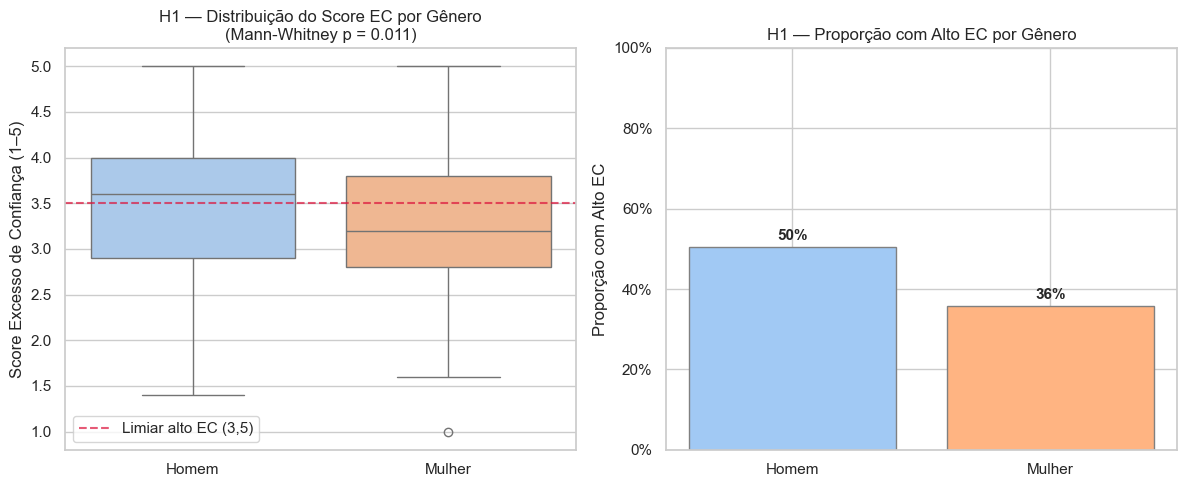

In [16]:
grupo_m = df.loc[df['genero'].str.strip() == 'Homem',  'score_ec'].dropna()
grupo_f = df.loc[df['genero'].str.strip() == 'Mulher', 'score_ec'].dropna()

stat_h1, p_h1 = mannwhitneyu(grupo_m, grupo_f, alternative='greater')
print(f"Homens   → Mediana EC: {grupo_m.median():.2f}  |  Média: {grupo_m.mean():.2f}  (n={len(grupo_m)})")
print(f"Mulheres → Mediana EC: {grupo_f.median():.2f}  |  Média: {grupo_f.mean():.2f}  (n={len(grupo_f)})")
print(f"\nMann-Whitney U = {stat_h1:.0f}  |  p-valor = {p_h1:.4f}")
print("✅ H1 SUPORTADA (p < 0.05)" if p_h1 < 0.05 else "❌ H1 NÃO suportada")

genero_ec = df[df['genero'].str.strip().isin(['Homem', 'Mulher'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=genero_ec, x='genero', y='score_ec',
            order=['Homem', 'Mulher'], palette='pastel', ax=axes[0])
axes[0].axhline(3.5, ls='--', color='crimson', alpha=0.7, label='Limiar alto EC (3,5)')
axes[0].set_title(f'H1 — Distribuição do Score EC por Gênero\n(Mann-Whitney p = {p_h1:.3f})')
axes[0].set_xlabel('')
axes[0].set_ylabel('Score Excesso de Confiança (1–5)')
axes[0].legend()

prop = genero_ec.groupby('genero')['alto_ec'].mean().reindex(['Homem', 'Mulher'])
bars = axes[1].bar(prop.index, prop.values,
                   color=sns.color_palette('pastel')[:2], edgecolor='grey')
for bar, val in zip(bars, prop.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.0%}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('H1 — Proporção com Alto EC por Gênero')
axes[1].set_ylabel('Proporção com Alto EC')
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

---
## H2 — Faixa Etária e Excesso de Confiança

### Hipótese
Adultos jovens (18–35 anos) apresentam score de excesso de confiança maior do que respondentes mais velhos (acima de 45 anos).

### Fundamentação Teórica
Glaser & Weber (2007) argumentam que a experiência financeira acumulada ao longo do tempo tende a calibrar melhor a autopercepção de competência. Indivíduos mais velhos já vivenciaram ciclos econômicos, erros de investimento e situações adversas que funcionam como "feedback da realidade", reduzindo gradualmente o excesso de confiança.

### Teste Estatístico: Kruskal-Wallis
Como comparamos **mais de dois grupos** (cinco faixas etárias), utilizamos o teste de Kruskal-Wallis — a versão não-paramétrica da ANOVA. Ele verifica se pelo menos um dos grupos apresenta distribuição de scores sistematicamente diferente dos demais, sem assumir normalidade.

### Sobre os Gráficos
- **Boxplot por faixa etária (esquerda):** Compara visualmente a distribuição do Score EC em cada grupo etário.
- **Dispersão com linha de tendência (direita):** Plota cada respondente como um ponto no plano (Idade × Score EC). A linha vermelha é calculada por regressão linear (mínimos quadrados) e resume a tendência geral. O coeficiente de correlação de Pearson `r` e seu p-valor indicam a força e a significância dessa tendência.

Kruskal-Wallis H = 5.87  |  p-valor = 0.1180
❌ H2 NÃO suportada

Mediana EC por faixa etária:
faixa_etaria
18–25    3.2
26–35    3.4
36–45    3.8
46–60    3.2
60+      3.0
Name: score_ec, dtype: float64


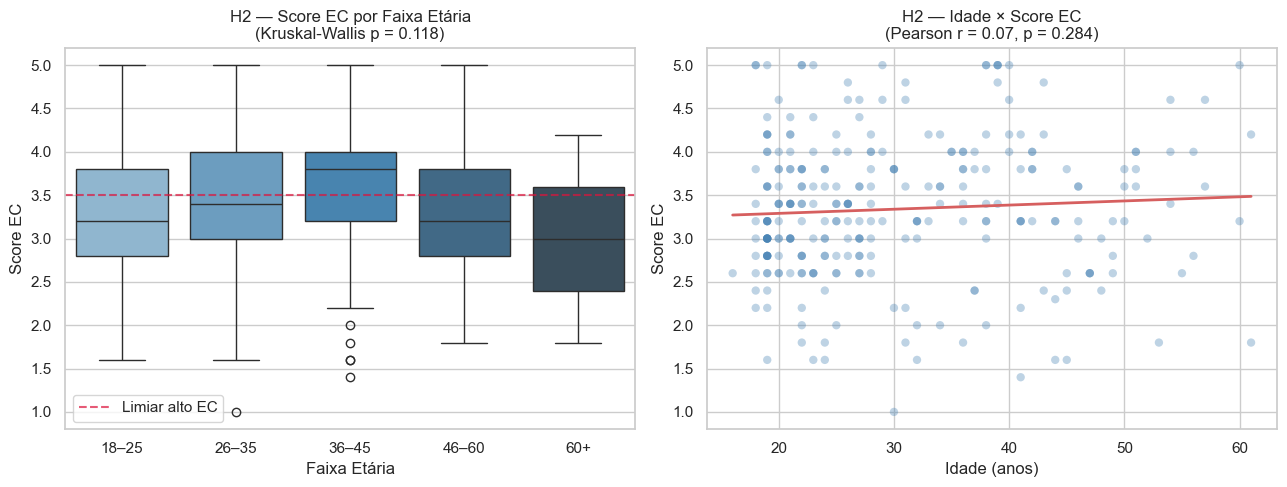

In [17]:
grupos_et = [df.loc[df['faixa_etaria'] == fx, 'score_ec'].dropna() for fx in labs_et]
grupos_et_val = [g for g in grupos_et if len(g) >= 5]

stat_h2, p_h2 = kruskal(*grupos_et_val)
print(f"Kruskal-Wallis H = {stat_h2:.2f}  |  p-valor = {p_h2:.4f}")
print("✅ H2 SUPORTADA (diferença significativa entre faixas)" if p_h2 < 0.05 else "❌ H2 NÃO suportada")
print('\nMediana EC por faixa etária:')
print(df.groupby('faixa_etaria', observed=True)['score_ec'].median().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df.dropna(subset=['faixa_etaria']), x='faixa_etaria',
            y='score_ec', order=labs_et, palette='Blues_d', ax=axes[0])
axes[0].axhline(3.5, ls='--', color='crimson', alpha=0.7, label='Limiar alto EC')
axes[0].set_title(f'H2 — Score EC por Faixa Etária\n(Kruskal-Wallis p = {p_h2:.3f})')
axes[0].set_xlabel('Faixa Etária')
axes[0].set_ylabel('Score EC')
axes[0].legend()

sc = df.dropna(subset=['idade', 'score_ec'])
axes[1].scatter(sc['idade'], sc['score_ec'], alpha=0.35, edgecolors='none', color='steelblue')
z = np.polyfit(sc['idade'], sc['score_ec'], 1)
xr = np.linspace(sc['idade'].min(), sc['idade'].max(), 100)
axes[1].plot(xr, np.poly1d(z)(xr), 'r-', lw=2)
r_h2, pv_h2 = stats.pearsonr(sc['idade'], sc['score_ec'])
axes[1].set_title(f'H2 — Idade × Score EC\n(Pearson r = {r_h2:.2f}, p = {pv_h2:.3f})')
axes[1].set_xlabel('Idade (anos)')
axes[1].set_ylabel('Score EC')

plt.tight_layout()
plt.show()

---
## H3 — Escolaridade e Excesso de Confiança

### Hipótese
Respondentes com ensino superior apresentam score de excesso de confiança maior do que os com ensino médio ou fundamental.

### Fundamentação Teórica
O **Efeito Dunning-Kruger** (Kruger & Dunning, 1999) postula que indivíduos com conhecimento intermediário tendem a superestimar sua competência mais do que especialistas — que reconhecem melhor os limites do próprio saber. No contexto financeiro, ter cursado uma graduação pode criar uma falsa sensação de domínio sobre temas complexos sem a experiência prática necessária.

### Teste Estatístico: Kruskal-Wallis
Múltiplos grupos de escolaridade → Kruskal-Wallis, da mesma forma que a H2.

### Sobre o Gráfico
Os níveis de escolaridade são ordenados da maior para a menor mediana de Score EC (eixo horizontal). Isso facilita identificar visualmente qual grupo apresenta maior autopercepção de competência financeira.

Distribuição de escolaridade:
escolaridade
Graduação em andamento         124
Doutorado completo              33
Graduação completa              31
Especialização completa         25
Mestrado em andamento           19
Ensino médio completo           14
Doutorado em andamento          13
Mestrado completo               11
Especialização em andamento      4
Ensino médio incompleto          1
Não estudei                      1
Ensino fundamental completo      1
Name: count, dtype: int64

Kruskal-Wallis H = 8.92  |  p-valor = 0.2586
❌ H3 NÃO suportada

Mediana EC por escolaridade:
escolaridade
Doutorado completo             3.6
Especialização completa        3.6
Especialização em andamento    3.5
Doutorado em andamento         3.4
Graduação completa             3.2
Graduação em andamento         3.2
Mestrado completo              3.2
Mestrado em andamento          3.2
Ensino fundamental completo    3.0
Ensino médio completo          2.8
Ensino médio incompleto        2.8
Não estudei       

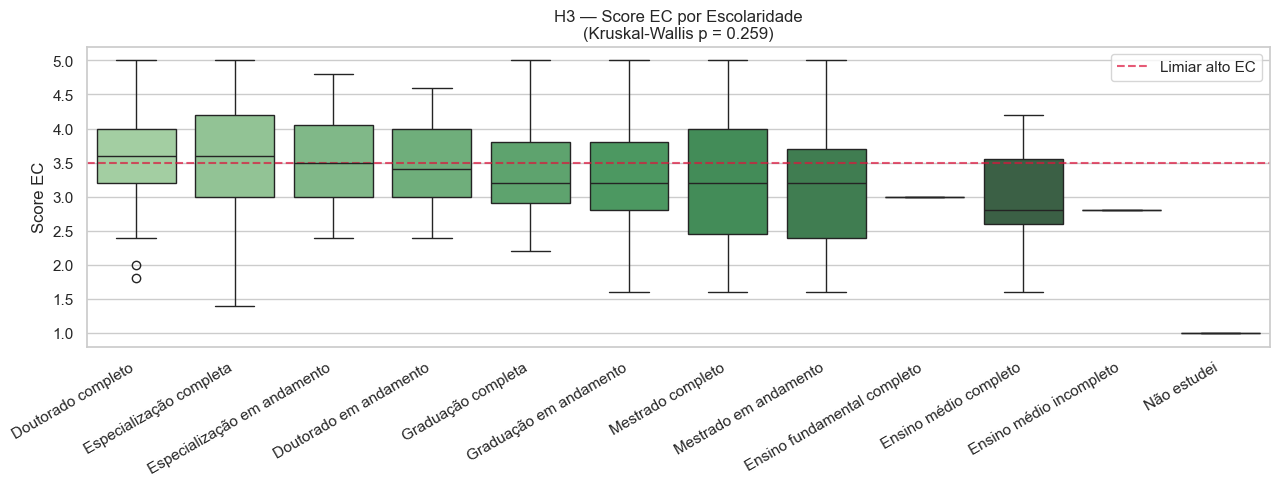

In [18]:
print('Distribuição de escolaridade:')
print(df['escolaridade'].value_counts())

grupos_esc = [g.dropna() for _, g in df.groupby('escolaridade')['score_ec'] if len(g) >= 5]
stat_h3, p_h3 = kruskal(*grupos_esc)
print(f"\nKruskal-Wallis H = {stat_h3:.2f}  |  p-valor = {p_h3:.4f}")
print("✅ H3 SUPORTADA" if p_h3 < 0.05 else "❌ H3 NÃO suportada")

med_esc = df.groupby('escolaridade')['score_ec'].median().sort_values(ascending=False)
print('\nMediana EC por escolaridade:')
print(med_esc.round(2))

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df.dropna(subset=['escolaridade']), x='escolaridade',
            y='score_ec', order=med_esc.index, palette='Greens_d', ax=ax)
ax.axhline(3.5, ls='--', color='crimson', alpha=0.7, label='Limiar alto EC')
ax.set_title(f'H3 — Score EC por Escolaridade\n(Kruskal-Wallis p = {p_h3:.3f})')
ax.set_xlabel('')
ax.set_ylabel('Score EC')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## H4 — Renda e Excesso de Confiança

### Hipótese
Respondentes com renda mensal mais elevada apresentam score de excesso de confiança maior.

### Fundamentação Teórica
Lusardi & Mitchell (2014) documentam que indivíduos de maior renda têm maior exposição a produtos financeiros (investimentos, crédito, seguros) e, consequentemente, uma percepção mais elevada de sua própria competência. Essa percepção pode superar o conhecimento real, especialmente na ausência de educação financeira formal.

### Teste Estatístico: Kruskal-Wallis
As faixas de renda são categorias ordenadas — Kruskal-Wallis verifica se há diferença estatística entre elas.

### Sobre o Gráfico
Os grupos de renda são ordenados da maior para a menor mediana de Score EC. Atenção: respondentes que escolheram `'Prefiro não responder'` são mantidos como uma categoria separada, pois essa omissão em si pode ser um indicador comportamental relevante.

Distribuição de renda:
renda
Mais de R$ 6.060,00                80
Entre R$ 1.213,00 e R$ 2.424,00    58
Entre R$ 607,00 e R$ 1.212,00      39
Entre R$ 3.637,00 e R$ 6.060,00    31
Entre R$ 2.425,00 e R$ 3.636,00    29
Sem rendimento                     16
Prefiro não responder              12
Até R$ 303,00                       7
Entre R$ 304,00 e R$ 606,00         5
Name: count, dtype: int64

Kruskal-Wallis H = 6.88  |  p-valor = 0.5500
❌ H4 NÃO suportada

Mediana EC por faixa de renda:
renda
Entre R$ 2.425,00 e R$ 3.636,00    3.6
Entre R$ 3.637,00 e R$ 6.060,00    3.6
Entre R$ 304,00 e R$ 606,00        3.4
Mais de R$ 6.060,00                3.4
Sem rendimento                     3.3
Até R$ 303,00                      3.2
Entre R$ 1.213,00 e R$ 2.424,00    3.2
Entre R$ 607,00 e R$ 1.212,00      3.0
Prefiro não responder              2.8
Name: score_ec, dtype: float64


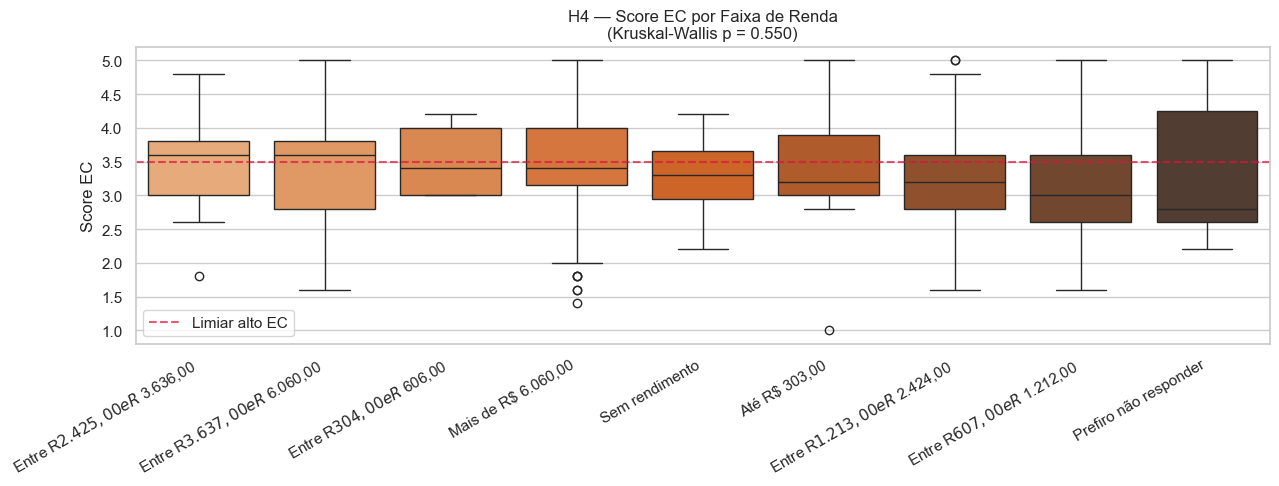

In [19]:
print('Distribuição de renda:')
print(df['renda'].value_counts())

grupos_renda = [g.dropna() for _, g in df.groupby('renda')['score_ec'] if len(g) >= 5]
stat_h4, p_h4 = kruskal(*grupos_renda)
print(f"\nKruskal-Wallis H = {stat_h4:.2f}  |  p-valor = {p_h4:.4f}")
print("✅ H4 SUPORTADA" if p_h4 < 0.05 else "❌ H4 NÃO suportada")

med_renda = df.groupby('renda')['score_ec'].median().sort_values(ascending=False)
print('\nMediana EC por faixa de renda:')
print(med_renda.round(2))

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df.dropna(subset=['renda']), x='renda',
            y='score_ec', order=med_renda.index, palette='Oranges_d', ax=ax)
ax.axhline(3.5, ls='--', color='crimson', alpha=0.7, label='Limiar alto EC')
ax.set_title(f'H4 — Score EC por Faixa de Renda\n(Kruskal-Wallis p = {p_h4:.3f})')
ax.set_xlabel('')
ax.set_ylabel('Score EC')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## H5 — Literacia Financeira Objetiva vs. Excesso de Confiança (Efeito Dunning-Kruger)

### Hipótese
Respondentes com menor acerto nas questões objetivas de literacia financeira apresentam score de excesso de confiança mais alto — ou seja, sabem menos, mas acreditam saber mais.

### Fundamentação Teórica
Lusardi & Mitchell (2011) mostram que indivíduos com baixa literacia financeira tendem a superestimar suas capacidades. Esse padrão é a manifestação clássica do **Efeito Dunning-Kruger**: a incompetência em uma área impede que o indivíduo reconheça sua própria incompetência — ele não sabe o suficiente para saber o que não sabe.

### Teste Estatístico: Correlação de Spearman
A correlação de Spearman (ρ, pronunciada "rô") mede a **força e direção** da relação entre duas variáveis ordinais ou não-normais. O resultado varia entre -1 e +1:
- **ρ próximo de -1:** Relação inversa forte (menos literacia → mais EC).
- **ρ próximo de 0:** Sem relação.
- **ρ próximo de +1:** Relação direta forte.

### Sobre os Gráficos
- **Dispersão (esquerda):** Cada ponto é um respondente. O eixo X é o Score LF (acertos) e o eixo Y é o Score EC. A linha vermelha resume a tendência.
- **Boxplot por nível de literacia (direita):** Os respondentes são agrupados em três categorias (baixa, média, alta literacia) para facilitar a comparação visual dos scores EC entre grupos com conhecimento real distinto.

Correlação de Spearman: ρ = 0.203  |  p-valor = 0.0007
✅ Correlação significativa
→ Direção oposta: maior literacia → maior excesso de confiança


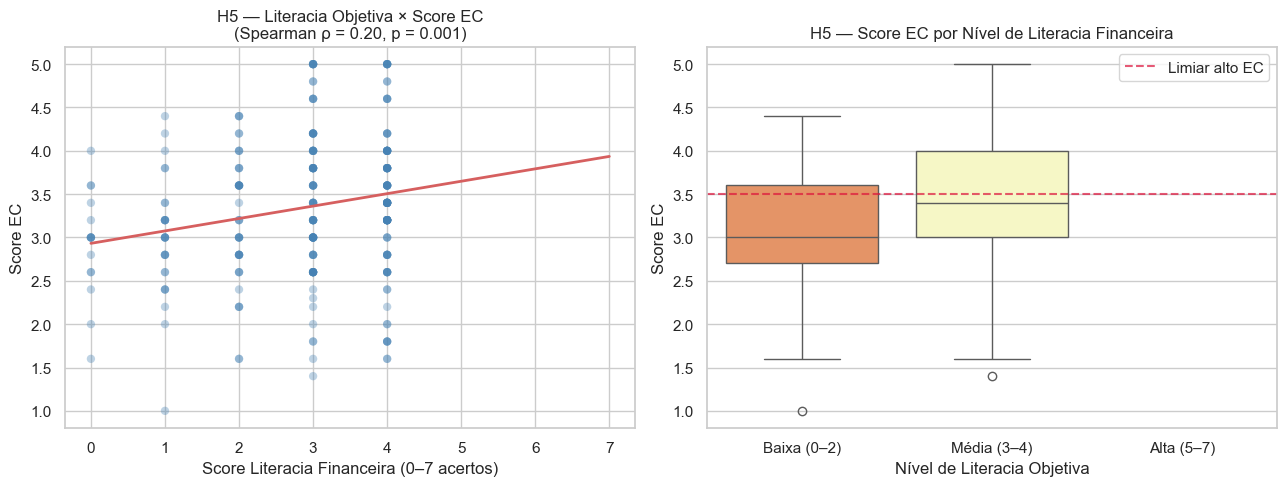

In [20]:
df_h5 = df[['score_lf', 'score_ec']].dropna()

rho_h5, p_h5 = spearmanr(df_h5['score_lf'], df_h5['score_ec'])
print(f"Correlação de Spearman: ρ = {rho_h5:.3f}  |  p-valor = {p_h5:.4f}")
print("✅ Correlação significativa" if p_h5 < 0.05 else "❌ Sem correlação significativa")
if rho_h5 < 0 and p_h5 < 0.05:
    print("→ Direção confirmada: menor literacia → maior excesso de confiança (Dunning-Kruger)")
elif rho_h5 > 0 and p_h5 < 0.05:
    print("→ Direção oposta: maior literacia → maior excesso de confiança")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_h5['score_lf'], df_h5['score_ec'],
                alpha=0.35, edgecolors='none', color='steelblue')
xr = np.linspace(0, 7, 50)
z = np.polyfit(df_h5['score_lf'], df_h5['score_ec'], 1)
axes[0].plot(xr, np.poly1d(z)(xr), 'r-', lw=2)
axes[0].set_title(f'H5 — Literacia Objetiva × Score EC\n(Spearman ρ = {rho_h5:.2f}, p = {p_h5:.3f})')
axes[0].set_xlabel('Score Literacia Financeira (0–7 acertos)')
axes[0].set_ylabel('Score EC')

df_h5 = df_h5.copy()
df_h5['lf_grupo'] = pd.cut(df_h5['score_lf'], bins=[-1, 2, 4, 7],
                            labels=['Baixa (0–2)', 'Média (3–4)', 'Alta (5–7)'])
sns.boxplot(data=df_h5, x='lf_grupo', y='score_ec', palette='RdYlGn', ax=axes[1])
axes[1].axhline(3.5, ls='--', color='crimson', alpha=0.7, label='Limiar alto EC')
axes[1].set_title('H5 — Score EC por Nível de Literacia Financeira')
axes[1].set_xlabel('Nível de Literacia Objetiva')
axes[1].set_ylabel('Score EC')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## H6 — Tipo de Localidade e Excesso de Confiança

### Hipótese
Residentes em áreas urbanas apresentam score de excesso de confiança maior do que os de áreas rurais ou periurbanas.

### Fundamentação Teórica
A maior oferta e variedade de produtos financeiros em centros urbanos (bancos, corretoras, fintechs, publicidade financeira) pode aumentar a familiaridade percebida com o tema, mesmo que o conhecimento objetivo não acompanhe essa exposição. A sensação de estar imerso em um ambiente financeiramente sofisticado pode inflar a autopercepção de competência.

### Teste Estatístico: Mann-Whitney U
Dois grupos (urbano vs. não-urbano) → Mann-Whitney U, da mesma forma que a H1.

### Sobre o Gráfico
O boxplot apresenta todos os tipos de localidade originais (sem agregação) para preservar a granularidade dos dados. Os grupos são ordenados da maior para a menor mediana de Score EC.

Tipos de localidade:
tipo_localidade
Área urbana (região central)                         165
Área urbana (periferia/comunidade/bairro popular)    108
Área rural (zona rural, sítio, fazenda, etc.)          3
Bairro 8 km da zona central                            1
Name: count, dtype: int64

Urbano   → Mediana EC: 3.20  (n=273)
Não-urb  → Mediana EC: 3.80  (n=4)
Mann-Whitney U = 414  |  p-valor = 0.7992
❌ H6 NÃO suportada


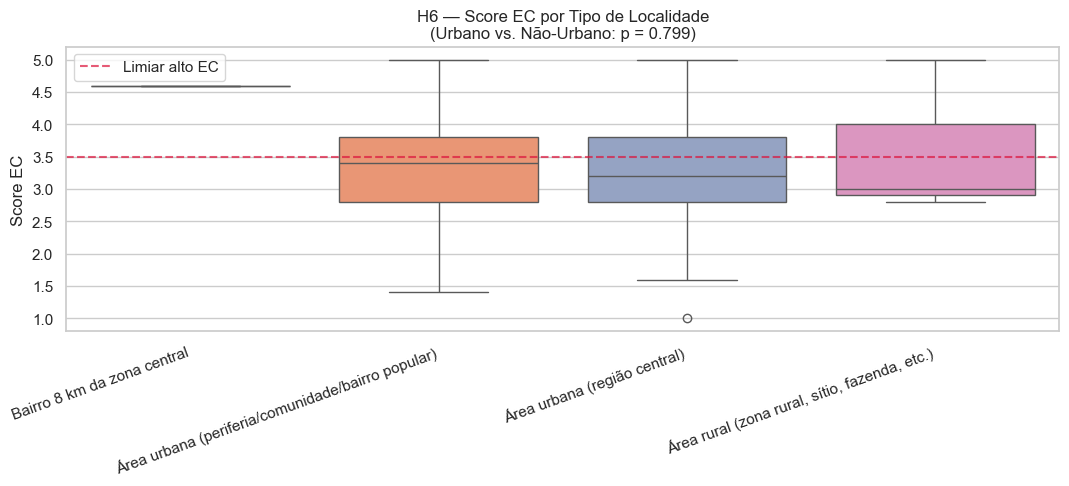

In [21]:
print('Tipos de localidade:')
print(df['tipo_localidade'].value_counts())

g_urb = df.loc[df['urbano'] == 1, 'score_ec'].dropna()
g_rur = df.loc[df['urbano'] == 0, 'score_ec'].dropna()

stat_h6, p_h6 = mannwhitneyu(g_urb, g_rur, alternative='greater')
print(f"\nUrbano   → Mediana EC: {g_urb.median():.2f}  (n={len(g_urb)})")
print(f"Não-urb  → Mediana EC: {g_rur.median():.2f}  (n={len(g_rur)})")
print(f"Mann-Whitney U = {stat_h6:.0f}  |  p-valor = {p_h6:.4f}")
print("✅ H6 SUPORTADA" if p_h6 < 0.05 else "❌ H6 NÃO suportada")

med_loc = df.groupby('tipo_localidade')['score_ec'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df.dropna(subset=['tipo_localidade']), x='tipo_localidade',
            y='score_ec', order=med_loc.index, palette='Set2', ax=ax)
ax.axhline(3.5, ls='--', color='crimson', alpha=0.7, label='Limiar alto EC')
ax.set_title(f'H6 — Score EC por Tipo de Localidade\n(Urbano vs. Não-Urbano: p = {p_h6:.3f})')
ax.set_xlabel('')
ax.set_ylabel('Score EC')
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

---
## H7 — Posse de Investimentos e Excesso de Confiança

### Hipótese
Respondentes que possuem algum produto de investimento apresentam score de excesso de confiança maior.

### Fundamentação Teórica
Odean (1999) documentou que investidores individuais tendem a negociar excessivamente — um comportamento diretamente associado ao excesso de confiança. A posse de investimentos indica não apenas uma decisão financeira tomada, mas também a autopercepção de que o respondente tem capacidade de gerir ativos, o que pode amplificar o viés.

### Teste Estatístico: Mann-Whitney U
Dois grupos (investidor vs. não-investidor) → Mann-Whitney U.

### Sobre os Gráficos
- **Boxplot (esquerda):** Distribuição do Score EC nos dois grupos.
- **Gráfico de barras (direita):** Proporção de alto EC em cada grupo, com os percentuais anotados diretamente nas barras para facilitar a leitura.

Investidores     → Mediana EC: 3.60  (n=163)
Não-investidores → Mediana EC: 3.00  (n=114)
Mann-Whitney U = 12986  |  p-valor = 0.0000
✅ H7 SUPORTADA


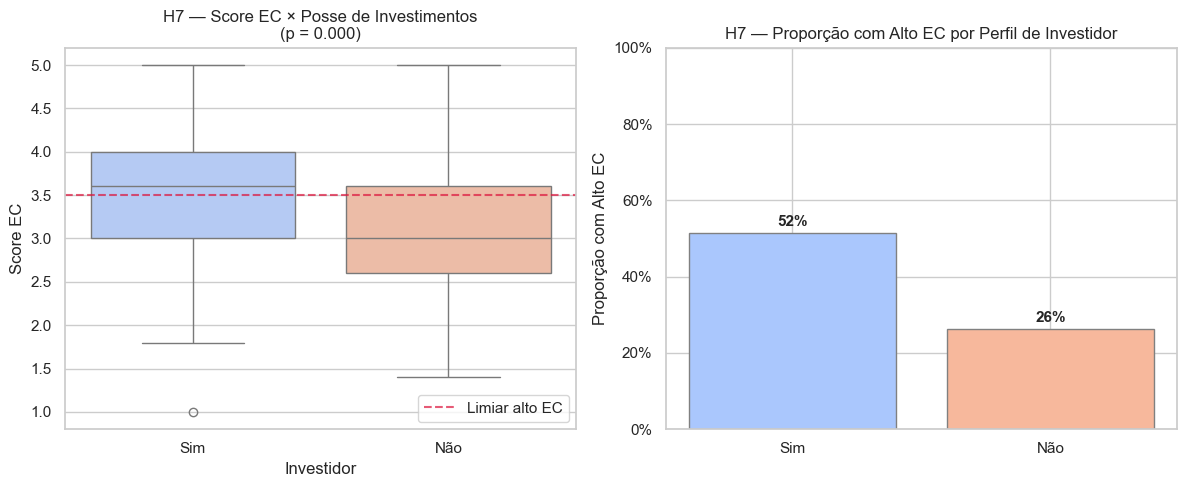

In [22]:
g_inv  = df.loc[df['investidor'] == 1, 'score_ec'].dropna()
g_ninv = df.loc[df['investidor'] == 0, 'score_ec'].dropna()

stat_h7, p_h7 = mannwhitneyu(g_inv, g_ninv, alternative='greater')
print(f"Investidores     → Mediana EC: {g_inv.median():.2f}  (n={len(g_inv)})")
print(f"Não-investidores → Mediana EC: {g_ninv.median():.2f}  (n={len(g_ninv)})")
print(f"Mann-Whitney U = {stat_h7:.0f}  |  p-valor = {p_h7:.4f}")
print("✅ H7 SUPORTADA" if p_h7 < 0.05 else "❌ H7 NÃO suportada")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_h7 = df.dropna(subset=['tem_investimento']).copy()
df_h7['Investidor'] = df_h7['investidor'].map({1: 'Sim', 0: 'Não'})

sns.boxplot(data=df_h7, x='Investidor', y='score_ec',
            order=['Sim', 'Não'], palette='coolwarm', ax=axes[0])
axes[0].axhline(3.5, ls='--', color='crimson', alpha=0.7, label='Limiar alto EC')
axes[0].set_title(f'H7 — Score EC × Posse de Investimentos\n(p = {p_h7:.3f})')
axes[0].set_ylabel('Score EC')
axes[0].legend()

prop_inv = df_h7.groupby('Investidor')['alto_ec'].mean().reindex(['Sim', 'Não'])
bars = axes[1].bar(prop_inv.index, prop_inv.values,
                   color=sns.color_palette('coolwarm', 2), edgecolor='grey')
for bar, val in zip(bars, prop_inv.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.0%}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('H7 — Proporção com Alto EC por Perfil de Investidor')
axes[1].set_ylabel('Proporção com Alto EC')
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

---
## H8 — Raça/Cor e Excesso de Confiança

### Hipótese
Há diferença estatisticamente significativa no score de excesso de confiança entre grupos de raça/cor.

### Fundamentação Teórica
Lusardi et al. (2017) documentam desigualdades estruturais no acesso a serviços financeiros, educação e renda entre grupos raciais. Essas diferenças moldam de formas distintas tanto o conhecimento financeiro objetivo quanto a autopercepção de competência. Grupos historicamente com menor acesso a produtos financeiros podem apresentar padrões distintos de autopercepção.

### Nota Metodológica
Esta hipótese é de natureza **exploratória** — não propõe uma direção específica, apenas verifica se há diferença. Caso o teste seja significativo, uma análise post-hoc (comparações par a par) seria necessária para identificar quais grupos diferem entre si.

### Teste Estatístico: Kruskal-Wallis
Múltiplos grupos raciais → Kruskal-Wallis.

Distribuição raça/cor:
raca_cor
Branca(o)      176
Parda(o)        77
Preta(o)        21
Amarela(o)       2
Indígena(o)      1
Name: count, dtype: int64

Kruskal-Wallis H = 5.05  |  p-valor = 0.0802
❌ H8 NÃO suportada

Mediana EC por raça/cor:
raca_cor
Preta(o)       3.6
Parda(o)       3.4
Branca(o)      3.2
Amarela(o)     3.1
Indígena(o)    1.0
Name: score_ec, dtype: float64


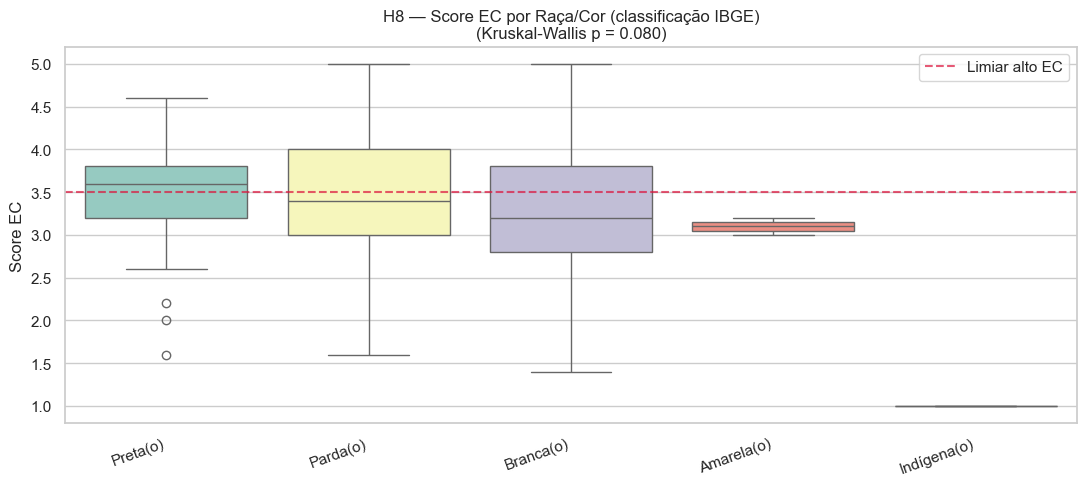

In [23]:
print('Distribuição raça/cor:')
print(df['raca_cor'].value_counts())

grupos_raca = [g.dropna() for _, g in df.groupby('raca_cor')['score_ec'] if len(g) >= 5]
stat_h8, p_h8 = kruskal(*grupos_raca)
print(f"\nKruskal-Wallis H = {stat_h8:.2f}  |  p-valor = {p_h8:.4f}")
print("✅ H8 SUPORTADA (diferença significativa)" if p_h8 < 0.05 else "❌ H8 NÃO suportada")

med_raca = df.groupby('raca_cor')['score_ec'].median().sort_values(ascending=False)
print('\nMediana EC por raça/cor:')
print(med_raca.round(2))

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df.dropna(subset=['raca_cor']), x='raca_cor',
            y='score_ec', order=med_raca.index, palette='Set3', ax=ax)
ax.axhline(3.5, ls='--', color='crimson', alpha=0.7, label='Limiar alto EC')
ax.set_title(f'H8 — Score EC por Raça/Cor (classificação IBGE)\n(Kruskal-Wallis p = {p_h8:.3f})')
ax.set_xlabel('')
ax.set_ylabel('Score EC')
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

---
## H9 — Dificuldade Financeira Prévia e Excesso de Confiança

### Hipótese
Respondentes que nunca vivenciaram dificuldades financeiras significativas apresentam score de excesso de confiança maior do que os que já passaram por tais dificuldades.

### Fundamentação Teórica
Kahneman (2011) argumenta que sistemas de feedback direto e concreto são essenciais para calibrar julgamentos humanos. A experiência de uma crise financeira pessoal funciona como um desses feedbacks: ela demonstra ao indivíduo de forma inequívoca os limites de seu controle e competência sobre as próprias finanças, reduzindo o excesso de confiança. Quem nunca viveu essa experiência mantém sua autopercepção positiva intacta.

### Teste Estatístico: Mann-Whitney U
Dois grupos (com vs. sem dificuldade financeira) → Mann-Whitney U. A hipótese é direcional: **sem dificuldade > com dificuldade**.

### Sobre o Gráfico — Violin Plot
O **violin plot** é uma variação do boxplot que também mostra a **forma da distribuição** dos dados. A parte mais larga do violino indica onde estão concentrados mais respondentes. A caixa interna funciona como um boxplot convencional. Esse tipo de gráfico é especialmente útil quando queremos verificar se a distribuição é bimodal (dois picos) ou assimétrica.

Sem dificuldade → Mediana EC: 3.20  (n=277)
Com dificuldade → Mediana EC: nan  (n=0)
Mann-Whitney U = nan  |  p-valor = nan
❌ H9 NÃO suportada


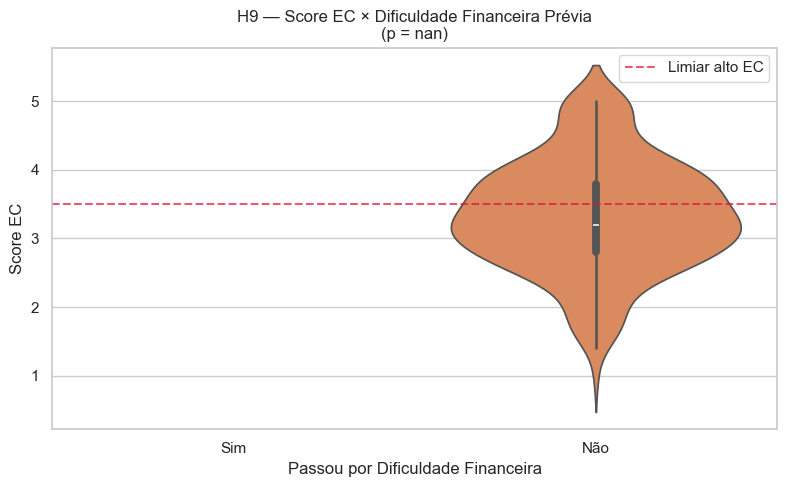

In [24]:
g_sem = df.loc[df['passou_dif_bin'] == 0, 'score_ec'].dropna()
g_com = df.loc[df['passou_dif_bin'] == 1, 'score_ec'].dropna()

stat_h9, p_h9 = mannwhitneyu(g_sem, g_com, alternative='greater')
print(f"Sem dificuldade → Mediana EC: {g_sem.median():.2f}  (n={len(g_sem)})")
print(f"Com dificuldade → Mediana EC: {g_com.median():.2f}  (n={len(g_com)})")
print(f"Mann-Whitney U = {stat_h9:.0f}  |  p-valor = {p_h9:.4f}")
print("✅ H9 SUPORTADA" if p_h9 < 0.05 else "❌ H9 NÃO suportada")

fig, ax = plt.subplots(figsize=(8, 5))
df_h9 = df.dropna(subset=['passou_dif_bin']).copy()
df_h9['Passou por Dificuldade Financeira'] = df_h9['passou_dif_bin'].map({1: 'Sim', 0: 'Não'})
sns.violinplot(data=df_h9, x='Passou por Dificuldade Financeira', y='score_ec',
               order=['Sim', 'Não'], palette='muted', inner='box', ax=ax)
ax.axhline(3.5, ls='--', color='crimson', alpha=0.7, label='Limiar alto EC')
ax.set_title(f'H9 — Score EC × Dificuldade Financeira Prévia\n(p = {p_h9:.3f})')
ax.set_ylabel('Score EC')
ax.legend()
plt.tight_layout()
plt.show()

---
## Painel Final — Correlações e Resumo das Hipóteses

### Mapa de Correlações de Spearman

O **heatmap de correlações** apresenta, de forma sintética, a força e a direção da relação entre o Score EC e todas as variáveis quantitativas disponíveis — e também entre essas variáveis entre si.

**Como interpretar:**
- Cores **vermelhas** indicam correlação positiva (quando uma variável sobe, a outra tende a subir).
- Cores **azuis** indicam correlação negativa (quando uma sobe, a outra tende a cair).
- Cores próximas ao **branco** indicam ausência de correlação.
- Os números dentro de cada célula são os coeficientes de Spearman (ρ), variando de -1 a +1.

**Nota técnica sobre a codificação das variáveis categóricas:**
Renda e escolaridade são convertidas para códigos numéricos ordinais usando `pd.Categorical().codes`, respeitando a ordem lógica de cada categoria. A variável `n_pessoas_casa` recebe tratamento especial: a categoria `'5 ou mais'` é convertida para o valor `5` (número inteiro), pois o restante das categorias já são numéricas — sem essa conversão, a coluna inteira seria tratada como texto e provocaria o erro `ValueError: could not convert string to float`.

In [25]:
# ── Mapeamentos ordinais com ordem lógica real ────────────────────────────────

# Renda: do menor para o maior
ordem_renda = [
    'Sem rendimento',
    'Até R$ 303,00',
    'Entre R$ 304,00 e R$ 606,00',
    'Entre R$ 607,00 e R$ 1.212,00',
    'Entre R$ 1.213,00 e R$ 2.424,00',
    'Entre R$ 2.425,00 e R$ 3.636,00',
    'Entre R$ 3.637,00 e R$ 6.060,00',
    'Mais de R$ 6.060,00',
    'Prefiro não responder',
]
renda_codes = pd.Categorical(
    df['renda'], categories=ordem_renda, ordered=True
).codes.astype(float)
renda_codes[renda_codes == -1] = np.nan
df['renda_cod'] = renda_codes

# Escolaridade: do menor para o maior nível
ordem_esc = [
    'Não estudei',
    'Ensino fundamental completo',
    'Ensino médio incompleto',
    'Ensino médio completo',
    'Graduação em andamento',
    'Graduação completa',
    'Especialização em andamento',
    'Especialização completa',
    'Mestrado em andamento',
    'Mestrado completo',
    'Doutorado em andamento',
    'Doutorado completo',
]
esc_codes = pd.Categorical(
    df['escolaridade'], categories=ordem_esc, ordered=True
).codes.astype(float)
esc_codes[esc_codes == -1] = np.nan
df['esc_cod'] = esc_codes

# n_pessoas_casa: '5 ou mais' → 5 (inteiro), restante já é numérico
df['pessoas_num'] = (
    df['n_pessoas_casa']
    .replace('5 ou mais', '5')
    .pipe(pd.to_numeric, errors='coerce')
)

print('Codificações criadas com sucesso.')
print(f"Renda cod  — únicos: {sorted(df['renda_cod'].dropna().unique())}")
print(f"Esc cod    — únicos: {sorted(df['esc_cod'].dropna().unique())}")
print(f"Pessoas num— únicos: {sorted(df['pessoas_num'].dropna().unique())}")

Codificações criadas com sucesso.
Renda cod  — únicos: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)]
Esc cod    — únicos: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0)]
Pessoas num— únicos: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


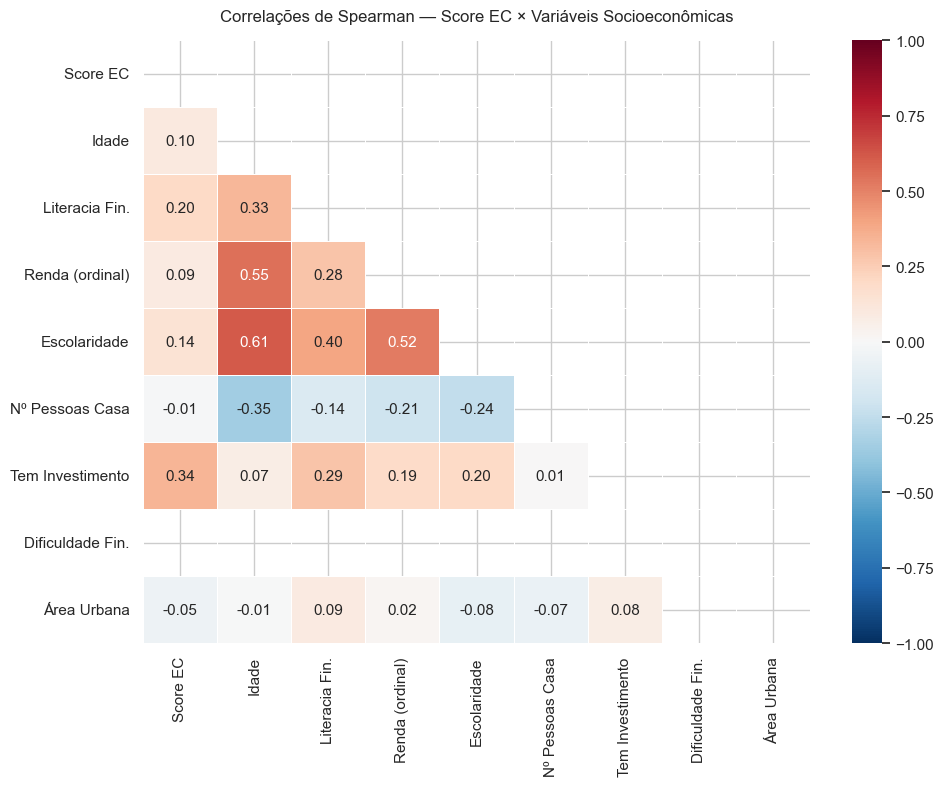

In [26]:
# ── Heatmap de correlações ────────────────────────────────────────────────────
corr_vars = {
    'score_ec':       'Score EC',
    'idade':          'Idade',
    'score_lf':       'Literacia Fin.',
    'renda_cod':      'Renda (ordinal)',
    'esc_cod':        'Escolaridade',
    'pessoas_num':    'Nº Pessoas Casa',
    'investidor':     'Tem Investimento',
    'passou_dif_bin': 'Dificuldade Fin.',
    'urbano':         'Área Urbana',
}

df_corr = df[list(corr_vars.keys())].rename(columns=corr_vars)
corr_matrix = df_corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Correlações de Spearman — Score EC × Variáveis Socioeconômicas',
             pad=14, fontsize=12)
plt.tight_layout()
plt.show()

In [27]:
# ── Tabela-resumo das hipóteses ───────────────────────────────────────────────
resumo = pd.DataFrame([
    {'H': 'H1', 'Variável':                'Gênero', 'Direção esperada': 'Homens > Mulheres',                          'Teste': 'Mann-Whitney U'},
    {'H': 'H2', 'Variável':          'Faixa etária', 'Direção esperada': 'Jovens (18–35) > Idosos (>45)',               'Teste': 'Kruskal-Wallis'},
    {'H': 'H3', 'Variável':          'Escolaridade', 'Direção esperada': 'Superior > Fundamental/Médio',                'Teste': 'Kruskal-Wallis'},
    {'H': 'H4', 'Variável':                 'Renda', 'Direção esperada': 'Maior renda → maior EC',                     'Teste': 'Kruskal-Wallis'},
    {'H': 'H5', 'Variável':   'Literacia Financeira', 'Direção esperada': 'Menor literacia → maior EC (Dunning-Kruger)', 'Teste': 'Spearman ρ'},
    {'H': 'H6', 'Variável':    'Tipo de localidade', 'Direção esperada': 'Urbano > Rural/Periurbano',                   'Teste': 'Mann-Whitney U'},
    {'H': 'H7', 'Variável': 'Posse de investimentos', 'Direção esperada': 'Investidor > Não-investidor',                'Teste': 'Mann-Whitney U'},
    {'H': 'H8', 'Variável':              'Raça/Cor', 'Direção esperada': 'Diferença entre grupos (exploratória)',       'Teste': 'Kruskal-Wallis'},
    {'H': 'H9', 'Variável': 'Dificuldade financeira', 'Direção esperada': 'Sem dificuldade → maior EC',                 'Teste': 'Mann-Whitney U'},
])

pd.set_option('display.max_colwidth', 60)
print('=== RESUMO DAS HIPÓTESES — Excesso de Confiança × Variáveis Sociodemográficas ===')
print(resumo.to_string(index=False))

=== RESUMO DAS HIPÓTESES — Excesso de Confiança × Variáveis Sociodemográficas ===
 H               Variável                            Direção esperada          Teste
H1                 Gênero                           Homens > Mulheres Mann-Whitney U
H2           Faixa etária               Jovens (18–35) > Idosos (>45) Kruskal-Wallis
H3           Escolaridade                Superior > Fundamental/Médio Kruskal-Wallis
H4                  Renda                      Maior renda → maior EC Kruskal-Wallis
H5   Literacia Financeira Menor literacia → maior EC (Dunning-Kruger)     Spearman ρ
H6     Tipo de localidade                   Urbano > Rural/Periurbano Mann-Whitney U
H7 Posse de investimentos                 Investidor > Não-investidor Mann-Whitney U
H8               Raça/Cor       Diferença entre grupos (exploratória) Kruskal-Wallis
H9 Dificuldade financeira                  Sem dificuldade → maior EC Mann-Whitney U


---
## Referências

- Barber, B. M., & Odean, T. (2001). Boys will be boys: Gender, overconfidence, and common stock investment. *Quarterly Journal of Economics*, 116(1), 261–292.
- Glaser, M., & Weber, M. (2007). Overconfidence and trading volume. *Geneva Risk and Insurance Review*, 32(1), 1–36.
- Kahneman, D. (2011). *Thinking, Fast and Slow*. Farrar, Straus and Giroux.
- Kruger, J., & Dunning, D. (1999). Unskilled and unaware of it. *Journal of Personality and Social Psychology*, 77(6), 1121–1134.
- Lusardi, A., & Mitchell, O. S. (2011). Financial literacy around the world. *Journal of Pension Economics and Finance*, 10(4), 497–508.
- Lusardi, A., & Mitchell, O. S. (2014). The economic importance of financial literacy. *Journal of Economic Literature*, 52(1), 5–44.
- Lusardi, A., Michaud, P.-C., & Mitchell, O. S. (2017). Optimal financial knowledge and wealth inequality. *Journal of Political Economy*, 125(2), 431–477.
- Odean, T. (1999). Do investors trade too much? *American Economic Review*, 89(5), 1279–1298.